In [ ]:
import numpy as np
from PIL import Image
from generation import *

In [147]:
img_albedo = Image.open('Earth_alb.png')
img_normal = Image.open('Earth_nrm.png')
img_mtl = Image.open('Earth_mtl.png')
img_mtl = img_mtl.resize((4096, 1024), Image.LANCZOS)
img_roughness = Image.open('Earth_rgh.png')
img_roughness = img_roughness.resize((4096, 1024), Image.LANCZOS)

albedo = np.array(img_albedo)
normal = np.array(img_normal)
mtl = np.array(img_mtl)
roughness = np.array(img_roughness)

print(albedo.shape, albedo.max(), albedo.min())
print(normal.shape, normal.max(), normal.min())
print(mtl.shape, mtl.max(), mtl.min())
print(roughness.shape, roughness.max(), roughness.min())

(1024, 4096, 4) 255 0
(1024, 4096, 4) 255 0
(1024, 4096, 4) 255 0
(1024, 4096, 4) 255 45


In [148]:
m = mtl[..., :3].astype(np.float32)
m = m / 255.0
m = np.linalg.norm(m, axis=-1)
m = (m - m.min()) / (m.max() - m.min())
print(m.shape, m.max(), m.min())

(1024, 4096) 1.0 0.0


In [150]:
r = roughness[..., :3].astype(np.float32)
r = r / 255.0
r = np.linalg.norm(r, axis=-1)
r = (r - r.min()) / (r.max() - r.min())
print(r.shape, r.max(), r.min())

(1024, 4096) 1.0 0.0


In [151]:
from scipy.ndimage import distance_transform_edt, gaussian_filter, zoom
# normal_hi = zoom(normal, (2, 2, 1), order=3)
n = normal[..., :3].astype(np.float32)
n = n / 255.0 * 2.0 - 1.0

length = np.linalg.norm(n, axis=2, keepdims=True)
n /= np.maximum(length, 1e-6)

Nx = n[..., 0]
Ny = n[..., 1]
Nz = n[..., 2] 

Ny = -Ny  # flip Y for image coordinates
print(Nx.shape)

eps = 1e-6
dzdx = Nx / (Nz + eps)
dzdy = Ny / (Nz + eps)

dzdx = gaussian_filter(dzdx, sigma=1.0)
dzdy = gaussian_filter(dzdy, sigma=1.0)

dzdx -= dzdx.mean()
dzdy -= dzdy.mean() 

h = np.zeros_like(Nx)

import numpy as np
from numpy.fft import fft2, ifft2

# divergence of the gradient field
dx = np.zeros_like(dzdx)
dy = np.zeros_like(dzdy)

dx[:, :-1] = dzdx[:, :-1] - dzdx[:, 1:]
dy[:-1, :] = dzdy[:-1, :] - dzdy[1:, :]

f = dx + dy

# FFT Poisson solve
H, W = f.shape
ky = np.fft.fftfreq(H)[:, None]  # column vector
kx = np.fft.fftfreq(W)[None, :]

denom = (2 * np.cos(2*np.pi*kx) +
         2 * np.cos(2*np.pi*ky) - 4)

denom[0, 0] = 1  # avoid divide by zero

h = np.real(ifft2(fft2(f) / denom))
print(h.shape, h.max(), h.min())
h = (h - h.min()) / (h.max() - h.min())

(1024, 4096)
(1024, 4096) 99.3588432793533 -21.41790073084911


In [160]:
land = (m < 0.2)
dist_land = distance_transform_edt(land)
dist_sea = distance_transform_edt(~land)
dist_sea = (dist_sea - dist_sea.min()) / (dist_sea.max() - dist_sea.min())
decline = (1-dist_sea)**20
decline = gaussian_filter(decline, sigma=0.1)
decline = (decline - decline.min()) / (decline.max() - decline.min())
decline = decline**5
decline = (decline - decline.min()) / (decline.max() - decline.min())
h_2 = h * decline
h_2 = (h_2 - h_2.min()) / (h_2.max() - h_2.min())

In [163]:
dzdx_h, dzdy_h = np.gradient(h)
Nz_h = 1.0 / np.sqrt(dzdx_h**2 + dzdy_h**2 + 1)
Nx_h = dzdx_h * Nz_h
Ny_h = dzdy_h * Nz_h

# normal difference
dNx = n[...,0] - Nx_h
dNy = n[...,1] - Ny_h

detail = gaussian_filter(dNx + dNy, sigma=0.5)
h_sharp = h + 0.01 * detail
h_sharp = (h_sharp - h_sharp.min()) / (h_sharp.max() - h_sharp.min())

In [120]:
h = zoom(h, 2, order=3)
h_sharp = zoom(h_sharp, 2, order=3)

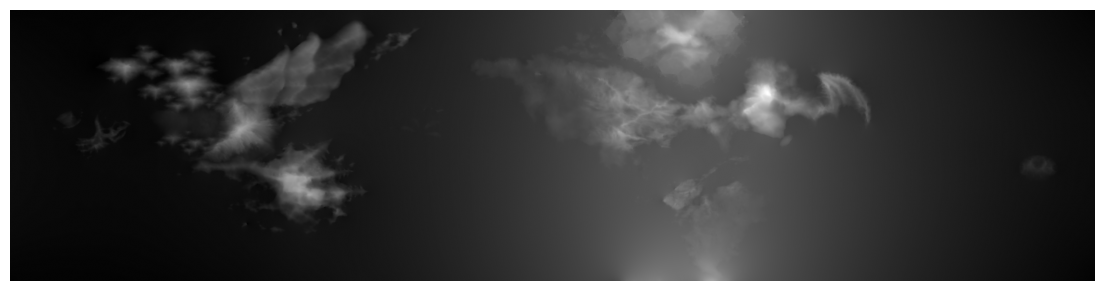

In [165]:
dist_land = distance_transform_edt(land)
dist_sea = distance_transform_edt(~land)
signed_dist = dist_land - dist_sea
signed_dist = (signed_dist - signed_dist.min()) / (signed_dist.max() - signed_dist.min())

from matplotlib import pyplot as plt
plt.figure(figsize=(14, 14))
plt.imshow(h, cmap="gray")
plt.axis("off")

Image.fromarray((h*65535).astype(np.uint16)).save('heightmap2.png')

In [55]:
width = 4095
height = 1023
A = []
z = []
for i in range(0, height):
    for j in range(0, width):
        if (land[i,j] == 1):
            x = (j / width) * 2 - 1
            y = (i / height) * 2 -1
            row = np.array([x**2, y**2, x*y, x, y, 1])
            A.append(row)
            z.append(h[i,j])

A = np.array(A)
z = np.array(z)

theta = np.linalg.inv(A.transpose()@A)@(A.transpose()@z)

In [60]:
construction = np.zeros_like(h)
for i in range(0, height):
    for j in range(0, width):
        x = (j / width) * 2 - 1
        y = (i / height) * 2 - 1
        construction[i,j] = theta[0]*x**2 + theta[1]*y**2 + theta[2]*x*y + theta[3]*x + theta[4]*y + theta[5]

In [67]:
h2 = h - construction
h2 = (h2 - h2.min()) / (h2.max() - h2.min())
print(h2.min(), h2.max())

0.0 1.0


In [155]:
seed = 4
rng = np.random.RandomState(seed)
perm = rng.permutation(256)

noise = simplex_fractal_noise(
    perm, 4096, 1024, scale=100, octaves=4, persistence=0.5, lacunarity=2, start_frequency=2**3
)

h_noise = h_sharp + 0.01*r
h_noise = (h_noise - h_noise.min()) / (h_noise.max() - h_noise.min())

In [176]:
here, _ = h.shape

y = np.linspace(0, 1, here)
gradient = np.sin(np.pi * y) ** 0.35  # smooth, zero at poles

# Apply gradient
h_smoothed = h * gradient[:, None]



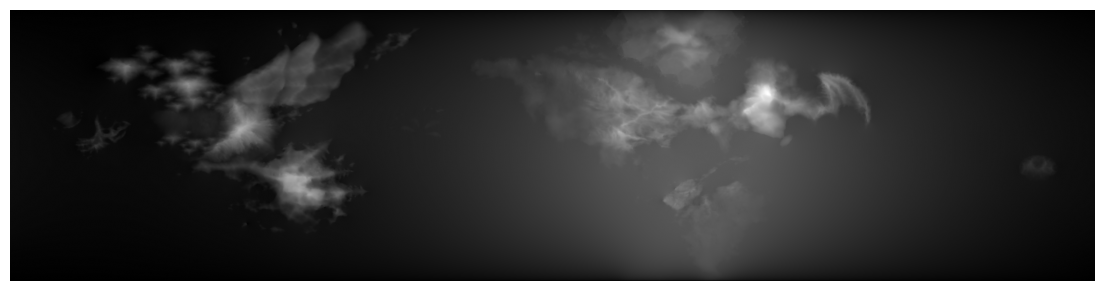

In [177]:
plt.figure(figsize=(14, 14))
plt.imshow(h_smoothed, cmap="gray")
plt.axis("off")

Image.fromarray((h_smoothed*65535).astype(np.uint16)).save('heightmap3.png')